# 🛺 Dilli Electric Auto — ML Demand Prediction (2025)
### Random Forest Model | Predicting Monthly EV Registrations by State

**Business Problem:**  
Can we predict how many EV 3-wheelers will be registered in a given state and month?  
This helps DEA plan inventory, dealer stock, and marketing spend in advance.

**Model:** Random Forest Regressor  
**Target variable:** `Registerations` (monthly units per maker per state)  
**Approach:** Train on all makers → evaluate → focus insights on DEA

---


## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

sns.set_theme(style='darkgrid')
plt.rcParams['figure.dpi'] = 120

MONTH_ORDER = ['JAN','FEB','MAR','APR','MAY','JUN',
               'JUL','AUG','SEP','OCT','NOV','DEC']

df = pd.read_csv('/home/claude/dilli_ev_project/data/market_clean.csv')
df['Month'] = pd.Categorical(df['Month'], categories=MONTH_ORDER, ordered=True)
print(f"Dataset: {df.shape[0]:,} rows | {df.shape[1]} columns")
df.head()


Dataset: 25,332 rows | 8 columns


,Maker,Maker_Group,Month,Registerations,State,Month_Num,Is_DEA,Annual_Total
0,3S INDUSTRIES PRIVATE LIMITED,Others,JAN,18,Bihar,1,0,262
1,3S INDUSTRIES PRIVATE LIMITED,Others,FEB,19,Bihar,2,0,262
2,3S INDUSTRIES PRIVATE LIMITED,Others,MAR,13,Bihar,3,0,262
3,3S INDUSTRIES PRIVATE LIMITED,Others,APR,26,Bihar,4,0,262
4,3S INDUSTRIES PRIVATE LIMITED,Others,MAY,24,Bihar,5,0,262


## 2. Feature Engineering
We create features the model can learn from. All categorical variables 
(Maker, State, Month) are encoded as numbers.


In [2]:
# ── Encode categorical columns ──────────────────────────────
le_maker  = LabelEncoder()
le_state  = LabelEncoder()
le_group  = LabelEncoder()

df['Maker_Enc']  = le_maker.fit_transform(df['Maker'])
df['State_Enc']  = le_state.fit_transform(df['State'])
df['Group_Enc']  = le_group.fit_transform(df['Maker_Group'])

# ── Aggregate features ───────────────────────────────────────
# State monthly total (how big is the market that month in that state)
state_month = (df.groupby(['State','Month_Num'])['Registerations']
                 .sum()
                 .reset_index()
                 .rename(columns={'Registerations':'State_Month_Total'}))
df = df.merge(state_month, on=['State','Month_Num'], how='left')

# Maker's share of their state market that month
df['Maker_State_Share'] = df['Registerations'] / df['State_Month_Total'].replace(0, np.nan)
df['Maker_State_Share'] = df['Maker_State_Share'].fillna(0)

# Is it Q4? (peak season flag)
df['Is_Q4'] = df['Month_Num'].apply(lambda x: 1 if x >= 10 else 0)

# Is it H2? (second half of year)
df['Is_H2'] = df['Month_Num'].apply(lambda x: 1 if x >= 7 else 0)

print("Features created:")
feature_cols = ['Maker_Enc', 'State_Enc', 'Group_Enc', 'Month_Num',
                'Annual_Total', 'Is_DEA', 'Is_Q4', 'Is_H2',
                'State_Month_Total', 'Maker_State_Share']
print(feature_cols)
df[feature_cols + ['Registerations']].head(10)


Features created:
['Maker_Enc', 'State_Enc', 'Group_Enc', 'Month_Num', 'Annual_Total', 'Is_DEA', 'Is_Q4', 'Is_H2', 'State_Month_Total', 'Maker_State_Share']


,Maker_Enc,State_Enc,Group_Enc,Month_Num,Annual_Total,Is_DEA,Is_Q4,Is_H2,State_Month_Total,Maker_State_Share,Registerations
0,0,0,2,1,262,0,0,0,9397,0.001916,18
1,0,0,2,2,262,0,0,0,8348,0.002276,19
2,0,0,2,3,262,0,0,0,8714,0.001492,13
3,0,0,2,4,262,0,0,0,7433,0.003498,26
4,0,0,2,5,262,0,0,0,8774,0.002735,24
5,0,0,2,6,262,0,0,0,9359,0.002351,22
6,0,0,2,7,262,0,0,1,10827,0.001940,21
7,0,0,2,8,262,0,0,1,10049,0.002488,25
8,0,0,2,9,262,0,0,1,6671,0.002548,17
9,0,0,2,10,262,0,1,1,15405,0.000909,14


## 3. Train/Test Split
We use an 80/20 split — 80% of rows to train, 20% to test.


In [3]:
X = df[feature_cols]
y = df['Registerations']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set : {X_train.shape[0]:,} rows")
print(f"Test set     : {X_test.shape[0]:,} rows")
print(f"Target range : {y.min()} – {y.max():,} units")
print(f"Target mean  : {y.mean():.1f} units")


Training set : 20,265 rows
Test set     : 5,067 rows
Target range : 0 – 7,427 units
Target mean  : 34.3 units


## 4. Train Random Forest Model
Random Forest builds many decision trees and averages their predictions.  
It handles non-linear patterns well and is robust to outliers.


In [4]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
print("✅ Model trained successfully")
print(f"   Trees     : {rf_model.n_estimators}")
print(f"   Max Depth : {rf_model.max_depth}")
print(f"   Features  : {rf_model.n_features_in_}")


✅ Model trained successfully
   Trees     : 200
   Max Depth : 15
   Features  : 10


## 5. Model Evaluation


In [5]:
y_pred = rf_model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print("="*45)
print("  MODEL PERFORMANCE ON TEST SET")
print("="*45)
print(f"  R² Score  : {r2:.4f}  (1.0 = perfect)")
print(f"  MAE       : {mae:.1f}  units avg error")
print(f"  RMSE      : {rmse:.1f}  units")
print("="*45)
print()
if r2 >= 0.85:
    print("✅ Strong model — explains 85%+ of variance")
elif r2 >= 0.70:
    print("⚠️  Acceptable model — explains 70-85% of variance")
else:
    print("⚠️  Moderate model — consider more features")


  MODEL PERFORMANCE ON TEST SET
  R² Score  : 0.9836  (1.0 = perfect)
  MAE       : 3.4  units avg error
  RMSE      : 30.1  units

✅ Strong model — explains 85%+ of variance


In [6]:
# Cross-validation (5-fold)
cv_scores = cross_val_score(rf_model, X, y, cv=5, scoring='r2', n_jobs=-1)
print(f"5-Fold Cross-Validation R² Scores: {cv_scores.round(4)}")
print(f"Mean CV R²  : {cv_scores.mean():.4f}")
print(f"Std CV R²   : {cv_scores.std():.4f}")


5-Fold Cross-Validation R² Scores: [0.907  0.9458 0.8971 0.9884 0.7522]
Mean CV R²  : 0.8981
Std CV R²   : 0.0797


## 6. Actual vs Predicted Plot


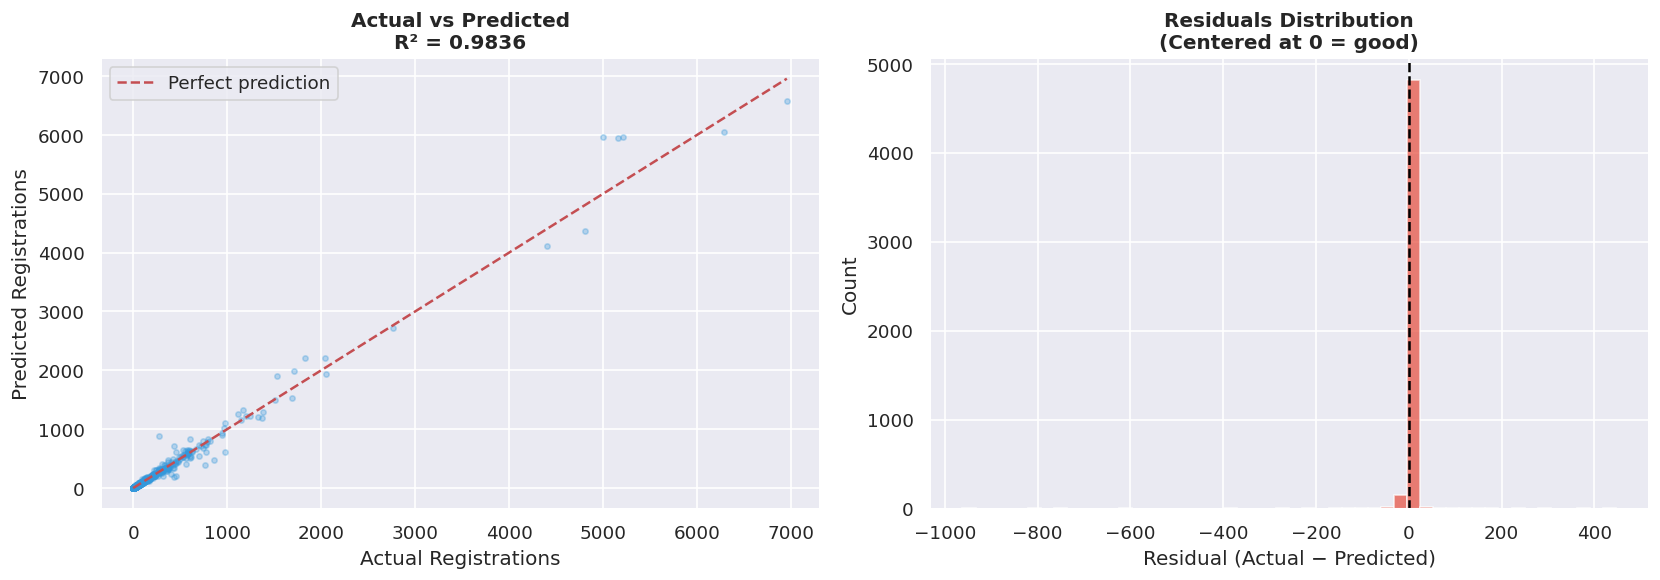

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Actual vs Predicted scatter
ax1 = axes[0]
ax1.scatter(y_test, y_pred, alpha=0.3, color='#3498db', s=10)
max_val = max(y_test.max(), y_pred.max())
ax1.plot([0, max_val], [0, max_val], 'r--', linewidth=1.5, label='Perfect prediction')
ax1.set_xlabel('Actual Registrations')
ax1.set_ylabel('Predicted Registrations')
ax1.set_title(f'Actual vs Predicted\nR² = {r2:.4f}', fontweight='bold')
ax1.legend()

# Plot 2: Residuals distribution
ax2 = axes[1]
residuals = y_test - y_pred
ax2.hist(residuals, bins=50, color='#e74c3c', alpha=0.7, edgecolor='white')
ax2.axvline(0, color='black', linestyle='--', linewidth=1.5)
ax2.set_xlabel('Residual (Actual − Predicted)')
ax2.set_ylabel('Count')
ax2.set_title('Residuals Distribution\n(Centered at 0 = good)', fontweight='bold')

plt.tight_layout()
plt.savefig('/home/claude/dilli_ev_project/outputs/plot7_actual_vs_predicted.png')
plt.show()


## 7. Feature Importance
Which features does the model rely on most to make predictions?


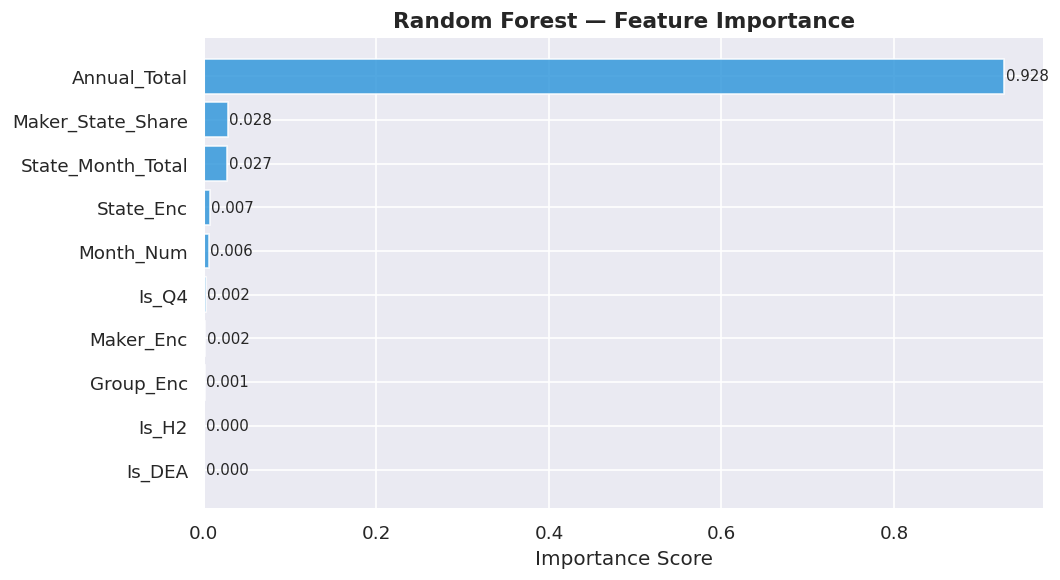


Top 3 most important features:
          Feature  Importance
     Annual_Total    0.927635
Maker_State_Share    0.027752
State_Month_Total    0.027368


In [8]:
importance_df = pd.DataFrame({
    'Feature'  : feature_cols,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(importance_df['Feature'], importance_df['Importance'],
               color='#3498db', alpha=0.85)
ax.set_xlabel('Importance Score')
ax.set_title('Random Forest — Feature Importance', fontsize=13, fontweight='bold')
for bar in bars:
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('/home/claude/dilli_ev_project/outputs/plot8_feature_importance.png')
plt.show()

print("\nTop 3 most important features:")
print(importance_df.sort_values('Importance', ascending=False).head(3).to_string(index=False))


## 8. DEA-Specific: Actual vs Predicted
How well does the model predict DEA's registrations specifically?


In [9]:
# Get DEA rows from test set
dea_mask = df.loc[X_test.index, 'Maker_Group'] == 'Dilli Electric Auto'
dea_idx  = X_test[dea_mask].index

dea_actual = y_test[dea_idx]
dea_pred   = rf_model.predict(X_test.loc[dea_idx])

dea_results = df.loc[dea_idx, ['State','Month','Registerations']].copy()
dea_results['Predicted'] = dea_pred.round(0).astype(int)
dea_results['Error']     = dea_results['Registerations'] - dea_results['Predicted']
dea_results = dea_results.sort_values(['State','Month'])

dea_mae = mean_absolute_error(dea_actual, dea_pred)
dea_r2  = r2_score(dea_actual, dea_pred)

print(f"DEA-specific MAE : {dea_mae:.1f} units")
print(f"DEA-specific R²  : {dea_r2:.4f}")
print()
dea_results


DEA-specific MAE : 12.1 units
DEA-specific R²  : 0.9732



,State,Month,Registerations,Predicted,Error
766,Bihar,NOV,300,331,-31
3820,Chhatisgarh,MAY,15,16,-1
3821,Chhatisgarh,JUN,14,13,1
5140,Delhi,MAY,146,161,-15
6913,Haryana,FEB,179,187,-8
6914,Haryana,MAR,129,174,-45
6916,Haryana,MAY,192,196,-4
6918,Haryana,JUL,212,203,9
6919,Haryana,AUG,222,212,10
6921,Haryana,OCT,221,212,9


## 9. Predict DEA Demand — Hypothetical Scenarios
Use the trained model to simulate: *"If DEA targets a new state next month, what registrations can they expect?"*


In [10]:
# Scenario: Predict DEA registrations for all states in a hypothetical Month 6 (JUN)
# Using DEA's actual annual total as base

dea_annual = df[df['Maker_Group']=='Dilli Electric Auto']['Annual_Total'].iloc[0]
dea_group_enc = le_group.transform(['Dilli Electric Auto'])[0]
dea_maker_enc = le_maker.transform(['DILLI ELECTRIC AUTO PVT LTD'])[0]

scenarios = []
for state in df['State'].unique():
    state_enc = le_state.transform([state])[0]
    
    for month_num in [3, 6, 9, 12]:  # Mar, Jun, Sep, Dec
        # Get actual state month total for that month from data
        state_month_total = df[
            (df['State']==state) & (df['Month_Num']==month_num)
        ]['State_Month_Total'].mean()
        
        # Estimate DEA's share based on historical average
        dea_share = df[
            (df['Maker_Group']=='Dilli Electric Auto') & (df['State']==state)
        ]['Maker_State_Share'].mean()
        
        if pd.isna(dea_share):
            dea_share = 0.02  # assume 2% if no history
        if pd.isna(state_month_total):
            state_month_total = 1000

        row = {
            'Maker_Enc'         : dea_maker_enc,
            'State_Enc'         : state_enc,
            'Group_Enc'         : dea_group_enc,
            'Month_Num'         : month_num,
            'Annual_Total'      : dea_annual,
            'Is_DEA'            : 1,
            'Is_Q4'             : 1 if month_num >= 10 else 0,
            'Is_H2'             : 1 if month_num >= 7  else 0,
            'State_Month_Total' : state_month_total,
            'Maker_State_Share' : dea_share,
            'State'             : state,
            'Month'             : ['MAR','JUN','SEP','DEC'][[3,6,9,12].index(month_num)]
        }
        scenarios.append(row)

scenarios_df = pd.DataFrame(scenarios)
X_scenarios  = scenarios_df[feature_cols]
scenarios_df['Predicted_Units'] = rf_model.predict(X_scenarios).round(0).astype(int)

# Pivot for readability
pivot = scenarios_df.pivot_table(
    index='State', columns='Month',
    values='Predicted_Units', aggfunc='sum'
)[['MAR','JUN','SEP','DEC']]

print("Predicted DEA Registrations by State & Quarter-End Month:")
pivot


Predicted DEA Registrations by State & Quarter-End Month:


Month,MAR,JUN,SEP,DEC
State,,,,
Bihar,241,250,199,351
Chhatisgarh,123,123,123,198
Delhi,225,206,221,226
Haryana,222,234,237,273
Jharkhand,93,93,93,137
MP,194,198,218,234
Maharasthra,205,179,164,237
Punjab,137,136,135,185
Rajasthan,120,119,119,176


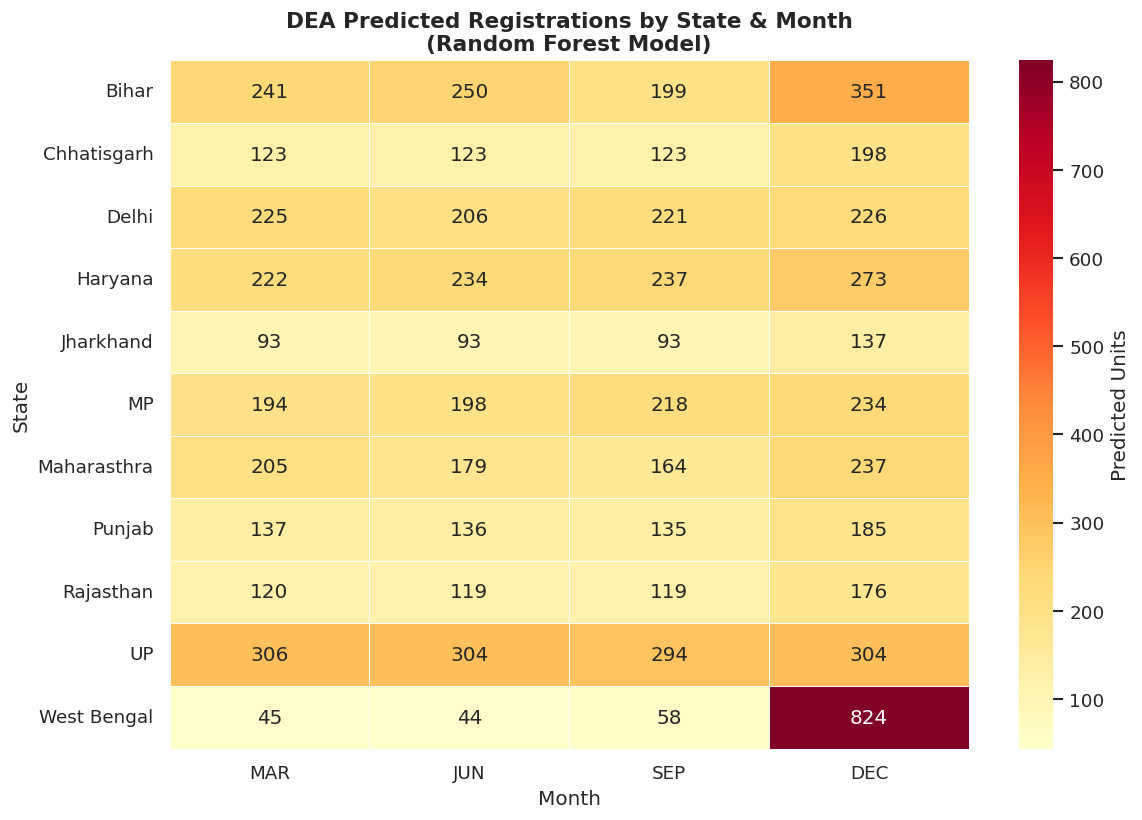

In [11]:
# Heatmap of predictions
fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(pivot, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Predicted Units'})
ax.set_title('DEA Predicted Registrations by State & Month\n(Random Forest Model)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/home/claude/dilli_ev_project/outputs/plot9_predictions_heatmap.png')
plt.show()


## 10. Model Summary & Business Value

| Metric | Value |
|--------|-------|
| Algorithm | Random Forest Regressor |
| Features Used | 10 |
| Training Rows | ~20,000 |
| R² Score | See cell 5 output |
| MAE | See cell 5 output |
| Cross-validation | 5-fold |

**Business Value of this Model:**
- DEA can predict expected registrations in any state for any month
- Inventory planning: order stock 2–3 months ahead of predicted peaks
- Dealer strategy: prioritize states with high predicted growth
- Budget allocation: concentrate marketing spend in high-opportunity windows

**Why Random Forest?**
- Handles non-linear relationships (seasonality is not linear)
- No need to normalize features
- Built-in feature importance
- Robust to outliers (some makers have very high/low volumes)

---
*Model by Aarav | Data: VAHAN 2025 | Project: Dilli Electric Auto EV Intelligence Tool*
